In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [3]:
# calculate params
def map_names(s):
    if 'Qwen' in s:
        return float(s.split("-")[-1].split("B")[0])
    elif 'gemma' in s:
        return float(s.split("-3-")[-1].split("b")[0])
    elif 'llama/Llama-2' in s:
        return float(s.split("-2-")[-1].split("b")[0])
    elif 'Llama-3' in s:
        return float(s.split("-3-")[-1].split("B")[0])
    else:
        return s

In [4]:
# import the results files
families = ['gemma_3', 'llama_2', 'llama_3', 'qwen_3']
d = {}

for f in families:
    df_ = pd.read_csv(f"../experiments/combined/{f}/results.csv")
    df_['family'] = f
    d.update({f:df_})

# combine
df = pd.concat(d.values())
df['params'] = df.apply(lambda x: map_names(x['model']), axis=1)

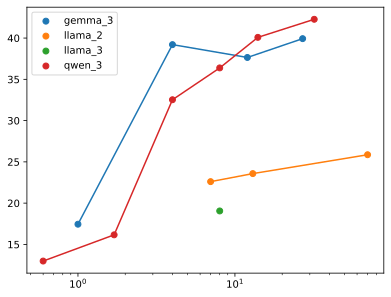

In [5]:
# plot combined plot per family
fig, ax = plt.subplots()

for family in df['family'].unique():
    family_df = df[df['family'] == family].sort_values('params')
    ax.scatter(family_df['params'], family_df['normalized_gain'], label=family)
    ax.plot(family_df['params'], family_df['normalized_gain'])

ax.set_xscale('log')
ax.legend()
plt.show()

# Bar chart 

In [39]:
# import the results files
families = ['gemma_3', 'llama_2', 'llama_3', 'qwen_3', 'claude_4_5', 'gpt_5', 'gpt_5_2', 'gemini_3']
d = {}

for f in families:
    try:
        df_ = pd.read_csv(f"../experiments/combined/{f}/results.csv")
    except:
        df_ = pd.read_csv(f"../experiments/combined/{f}/predictions_simulatability_analysis.csv")
    df_['family'] = f
    d.update({f:df_})

# combine
df = pd.concat(d.values())

df = df.replace({'gpt_5_2': 'gpt_5'})

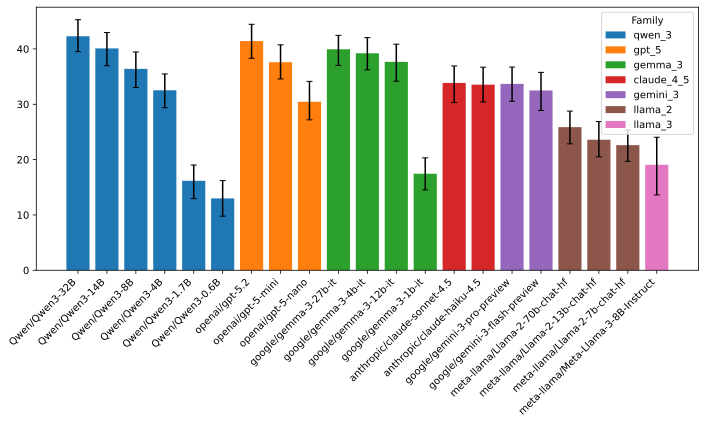

In [41]:
# by model family

df.sort_values('normalized_gain', inplace=True, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate error bar sizes (distance from the mean)
yerr_lower = df['normalized_gain'] - df['norm_gain_ci_lower']
yerr_upper = df['norm_gain_ci_upper'] - df['normalized_gain']

families = df['family'].unique()
colors = plt.cm.tab10(range(len(families)))  # or tab20 for more families
color_map = dict(zip(families, colors))

# Plot bars with family colours
for family in families:
    mask = df['family'] == family
    ax.bar(df.loc[mask, 'model'], df.loc[mask, 'normalized_gain'],
           yerr=[yerr_lower[mask], yerr_upper[mask]],
           capsize=3,
           color=color_map[family],
           label=family)

plt.xticks(rotation=45, ha='right')
plt.legend(title='Family')
plt.tight_layout()

In [ ]:
df